Import Data

In [ ]:
import pandas as pd

df = pd.read_csv("gold_data_2015_25.csv")#csv orgin:https://www.kaggle.com/datasets/mdanwarhossain200110/gold-price-2015-2025?select=gold_data_2015_25.csv

In [77]:
print(df.shape)

(2666, 6)


In [ ]:
df.head()#show first 5 rows of the CSV

,Date,SPX,GLD,USO,SLV,EUR/USD
0,2015-01-02,2058.199951,114.080002,159.119995,15.11,1.208941
1,2015-01-05,2020.579956,115.800003,150.320007,15.50,1.194643
2,2015-01-06,2002.609985,117.120003,144.399994,15.83,1.193902
3,2015-01-07,2025.900024,116.430000,146.960007,15.85,1.187536
4,2015-01-08,2062.139893,115.940002,148.399994,15.64,1.183600


In [ ]:
df.info()#understand the data types

<class 'pandas.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2666 non-null   str    
 1   SPX      2666 non-null   float64
 2   GLD      2666 non-null   float64
 3   USO      2666 non-null   float64
 4   SLV      2666 non-null   float64
 5   EUR/USD  2666 non-null   float64
dtypes: float64(5), str(1)
memory usage: 125.1 KB


In [ ]:
df.describe()#show summary statistics

,SPX,GLD,USO,SLV,EUR/USD
count,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,3504.231271,158.601665,80.319745,19.414055,1.118508
std,1212.323340,47.245813,27.665948,4.972436,0.052239
min,1829.079956,100.500000,17.040001,11.210000,0.959619
25%,2467.489929,120.650002,67.842497,15.530000,1.083887
50%,3168.685059,154.665001,78.254997,17.415000,1.115219
75%,4373.047607,178.547501,93.279999,22.547500,1.156076
max,6468.540039,316.290009,166.559998,35.720001,1.251001


In [ ]:
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
#check for duplicates and missing values

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64
Duplicates: 0


Filtering and Grouping

In [ ]:
df['Date'] = pd.to_datetime(df['Date']) #change  date format from str to datetime

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     2666 non-null   datetime64[us]
 1   SPX      2666 non-null   float64       
 2   GLD      2666 non-null   float64       
 3   USO      2666 non-null   float64       
 4   SLV      2666 non-null   float64       
 5   EUR/USD  2666 non-null   float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 125.1 KB


In [83]:
recent_gold = df[df['Date'] >= '2020-01-01'].copy() #find recent gold data starting 2020
recent_gold.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
1255,2020-01-02,3257.850098,143.949997,102.480003,16.809999,1.122083
1256,2020-01-03,3234.850098,145.860001,105.440002,16.840000,1.117144
1257,2020-01-06,3246.280029,147.389999,105.279999,16.940001,1.116196
1258,2020-01-07,3237.179932,147.970001,105.040001,17.170000,1.119799
1259,2020-01-08,3253.050049,146.860001,101.279999,16.930000,1.115474


In [ ]:
print(recent_gold.shape)#show the shape of the filtered DataFrame

(1411, 6)


In [110]:
df['Year'] = df['Date'].dt.year
df

,Date,SPX,GLD,USO,SLV,EUR/USD,Year
0,2015-01-02,2058.199951,114.080002,159.119995,15.110000,1.208941,2015
1,2015-01-05,2020.579956,115.800003,150.320007,15.500000,1.194643,2015
2,2015-01-06,2002.609985,117.120003,144.399994,15.830000,1.193902,2015
3,2015-01-07,2025.900024,116.430000,146.960007,15.850000,1.187536,2015
4,2015-01-08,2062.139893,115.940002,148.399994,15.640000,1.183600,2015
...,...,...,...,...,...,...,...
2661,2025-08-08,6389.450195,313.049988,73.300003,34.880001,1.167665,2025
2662,2025-08-11,6373.450195,308.549988,73.800003,34.180000,1.164795,2025
2663,2025-08-12,6445.759766,308.269989,72.949997,34.410000,1.161845,2025
2664,2025-08-13,6466.580078,309.209991,72.459999,35.000000,1.167706,2025


Plot(find the average gold price change from 2015 to 2025)

In [111]:
yearly_gold = df.groupby('Year')['GLD'].agg(['mean', 'min', 'max', 'count'])
yearly_gold

,mean,min,max,count
Year,,,,
2015,111.146032,100.500000,125.230003,252
2016,119.362619,102.889999,130.520004,252
2017,119.714940,110.470001,128.130005,249
2018,120.177331,111.099998,128.830002,251
2019,131.561872,119.940002,146.660004,251
2020,166.653755,138.039993,193.889999,253
2021,168.311230,157.490005,182.869995,252
2022,167.905139,151.229996,191.509995,251
2023,180.449880,168.350006,192.589996,250


The line polt here is the best way to visualize the change of average yearly gold price from 2015 to 2025

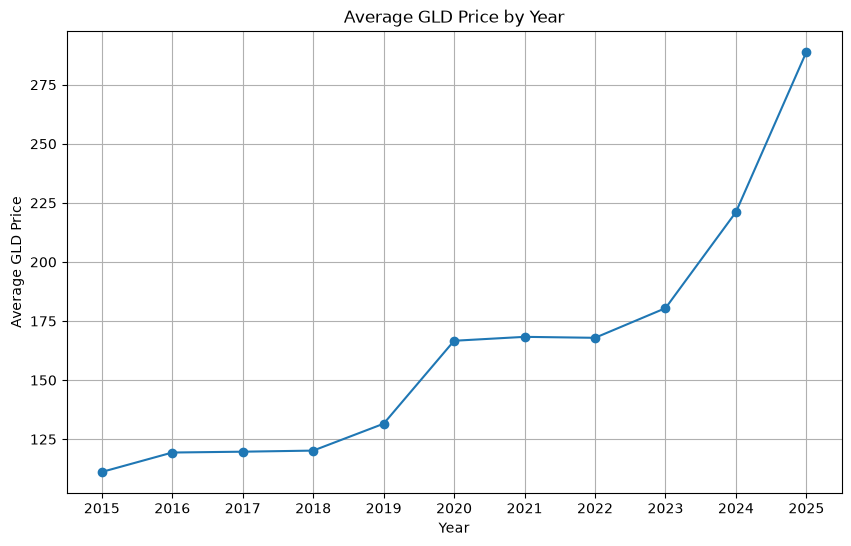

In [86]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

plt.plot(yearly_gold.index,yearly_gold['mean'],marker='o')
plt.title('Average GLD Price by Year')
plt.xlabel('Year')
plt.ylabel('Average GLD Price')
plt.xticks(yearly_gold.index)
plt.grid(True)

plt.show()

The chart shows a general upward trend in average GLD values, with a much stronger increase after 2023. The 2025 value should be interpreted carefully because the dataset only includes data through August 14, 2025.

Machine Learning(Predict the average gold price for september 2025)

In [87]:
gold_2025 = df[df['Date'].dt.year == 2025].copy()

In [88]:
monthly_2025 = gold_2025.groupby(gold_2025['Date'].dt.month)['GLD'].mean().reset_index()
monthly_2025.columns = ['Month', 'Average_GLD']
monthly_2025

,Month,Average_GLD
0,1,250.425500
1,2,267.119473
2,3,275.387142
3,4,296.025002
4,5,302.891427
5,6,308.875499
6,7,307.725911
7,8,310.112994


In [89]:
X = monthly_2025[['Month']].values
y = monthly_2025['Average_GLD']
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X,y)
predicted_sep = model.predict([[9]])
print(f"Predicted average GLD price for September 2025: {predicted_sep[0]:.2f}")

Predicted average GLD price for September 2025: 328.83


Polars Analysis

Import data

In [ ]:
import polars as pl
## Load the dataset using Polars
df_pl = pl.read_csv("gold_data_2015_25.csv")
df_pl.shape

(2666, 6)

In [91]:
df_pl.head()

Date,SPX,GLD,USO,SLV,EUR/USD
str,f64,f64,f64,f64,f64
"""2015-01-02""",2058.199951,114.080002,159.119995,15.11,1.208941
"""2015-01-05""",2020.579956,115.800003,150.320007,15.5,1.194643
"""2015-01-06""",2002.609985,117.120003,144.399994,15.83,1.193902
"""2015-01-07""",2025.900024,116.43,146.960007,15.85,1.187536
"""2015-01-08""",2062.139893,115.940002,148.399994,15.64,1.1836


In [92]:
df_pl.schema

Schema([('Date', String),
        ('SPX', Float64),
        ('GLD', Float64),
        ('USO', Float64),
        ('SLV', Float64),
        ('EUR/USD', Float64)])

In [93]:
df_pl.describe()

statistic,Date,SPX,GLD,USO,SLV,EUR/USD
str,str,f64,f64,f64,f64,f64
"""count""","""2666""",2666.0,2666.0,2666.0,2666.0,2666.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,0.0
"""mean""",null,3504.231271,158.601665,80.319745,19.414055,1.118508
"""std""",null,1212.32334,47.245813,27.665948,4.972436,0.052239
"""min""","""2015-01-02""",1829.079956,100.5,17.040001,11.21,0.959619
"""25%""",null,2467.419922,120.650002,67.839996,15.53,1.083882
"""50%""",null,3168.800049,154.669998,78.269997,17.42,1.115237
"""75%""",null,4373.200195,178.550003,93.279999,22.549999,1.156109
"""max""","""2025-08-14""",6468.540039,316.290009,166.559998,35.720001,1.251001


In [94]:
df_pl.null_count()

Date,SPX,GLD,USO,SLV,EUR/USD
u32,u32,u32,u32,u32,u32
0,0,0,0,0,0


In [95]:
df_pl.is_duplicated().sum()

0

Filtering and grouping

In [ ]:
df_pl = df_pl.with_columns(pl.col("Date").str.to_date("%Y-%m-%d"))#Convert Date from string to Polars Date type

In [97]:
df_pl.schema

Schema([('Date', Date),
        ('SPX', Float64),
        ('GLD', Float64),
        ('USO', Float64),
        ('SLV', Float64),
        ('EUR/USD', Float64)])

In [ ]:
recent_gold_pl = df_pl.filter(pl.col("Date") >= pl.date(2020, 1, 1))# Filter data starting from 2020
recent_gold_pl.head()

Date,SPX,GLD,USO,SLV,EUR/USD
date,f64,f64,f64,f64,f64
2020-01-02,3257.850098,143.949997,102.480003,16.809999,1.122083
2020-01-03,3234.850098,145.860001,105.440002,16.84,1.117144
2020-01-06,3246.280029,147.389999,105.279999,16.940001,1.116196
2020-01-07,3237.179932,147.970001,105.040001,17.17,1.119799
2020-01-08,3253.050049,146.860001,101.279999,16.93,1.115474


In [99]:
recent_gold_pl.shape

(1411, 6)

In [100]:
df_pl = df_pl.with_columns(pl.col("Date").dt.year().alias("Year"))
df_pl

Date,SPX,GLD,USO,SLV,EUR/USD,Year
date,f64,f64,f64,f64,f64,i32
2015-01-02,2058.199951,114.080002,159.119995,15.11,1.208941,2015
2015-01-05,2020.579956,115.800003,150.320007,15.5,1.194643,2015
2015-01-06,2002.609985,117.120003,144.399994,15.83,1.193902,2015
2015-01-07,2025.900024,116.43,146.960007,15.85,1.187536,2015
2015-01-08,2062.139893,115.940002,148.399994,15.64,1.1836,2015
…,…,…,…,…,…,…
2025-08-08,6389.450195,313.049988,73.300003,34.880001,1.167665,2025
2025-08-11,6373.450195,308.549988,73.800003,34.18,1.164795,2025
2025-08-12,6445.759766,308.269989,72.949997,34.41,1.161845,2025


Visualization

In [ ]:
yearly_gold_pl = (df_pl.group_by("Year").agg(pl.col("GLD").mean().alias("mean"),pl.col("GLD").min().alias("min"),pl.col("GLD").max().alias("max"),pl.col("GLD").count().alias("count")).sort("Year"))
yearly_gold_pl
# Calculate yearly GLD summary statistics

Year,mean,min,max,count
i32,f64,f64,f64,u32
2015,111.146032,100.5,125.230003,252
2016,119.362619,102.889999,130.520004,252
2017,119.71494,110.470001,128.130005,249
2018,120.177331,111.099998,128.830002,251
2019,131.561872,119.940002,146.660004,251
…,…,…,…,…
2021,168.31123,157.490005,182.869995,252
2022,167.905139,151.229996,191.509995,251
2023,180.44988,168.350006,192.589996,250


The line polt here is the best way to visualize the change of average yearly gold price from 2015 to 2025

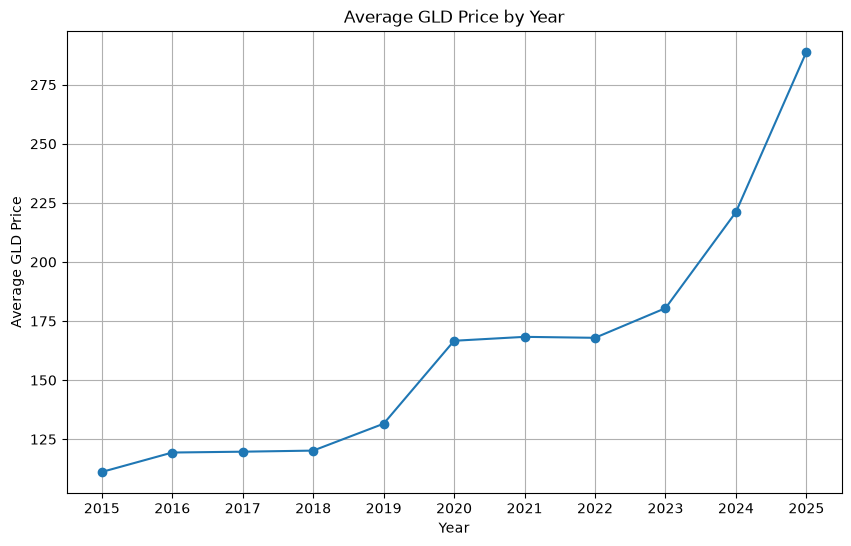

In [102]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    yearly_gold_pl["Year"],
    yearly_gold_pl["mean"],
    marker="o"
)

plt.title("Average GLD Price by Year")
plt.xlabel("Year")
plt.ylabel("Average GLD Price")
plt.xticks(yearly_gold_pl["Year"])
plt.grid(True)

plt.show()

The chart shows a general upward trend in average GLD values, with a much stronger increase after 2023. The 2025 value should be interpreted carefully because the dataset only includes data through August 14, 2025.

Machine learning for predict september 2025 gold price

In [103]:
gold_2025_pl = df_pl.filter(pl.col("Date").dt.year() == 2025)

In [104]:
monthly_2025_pl = (gold_2025_pl.with_columns(pl.col("Date").dt.month().alias("Month")).group_by("Month").agg(pl.col("GLD").mean().alias("Average_GLD")).sort("Month"))
monthly_2025_pl

Month,Average_GLD
i8,f64
1,250.4255
2,267.119473
3,275.387142
4,296.025002
5,302.891427
6,308.875499
7,307.725911
8,310.112994


In [ ]:
X_pl = monthly_2025_pl.select("Month").to_numpy()
y_pl = monthly_2025_pl["Average_GLD"].to_numpy()
# Convert Polars results to NumPy arrays for scikit-learn

In [106]:
from sklearn.linear_model import LinearRegression

model_pl = LinearRegression()
model_pl.fit(X_pl, y_pl)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[8.67]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,250.8
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[6.48]


In [107]:
predicted_sep_pl = model_pl.predict([[9]])

print(f"Predicted average GLD price for September 2025: {predicted_sep_pl[0]:.2f}")

Predicted average GLD price for September 2025: 328.83
